# SHAP Explainability Analysis

Interpreting which feature differences drive pairwise flat preferences,  
using SHAP (SHapley Additive exPlanations) on our two best models:
- **HistGBM** (best tree model, AUC 0.901) — via TreeExplainer
- **MLP 1-layer / RankNet** (best overall, AUC 0.910) — via KernelExplainer

## Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

shap.initjs()

/Users/caspe2/NUS/Y3S2/CS3264/cs3264-hdb/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Models

In [2]:
df = pd.read_csv("df_pairwise.csv")

weight_cols = [
    "weight_transport", "weight_essentials", "weight_lifestyle",
    "weight_recreation", "weight_health", "weight_storey",
    "weight_lease", "weight_office", "weight_parents",
]
diff_cols = [c for c in df.columns if c.startswith("diff_")]
feature_cols = weight_cols + diff_cols

# Same split as model_pairwise.ipynb
user_ids = df["user_id"].unique()
train_users, val_users = train_test_split(user_ids, test_size=0.2, random_state=42)
val_df = df[df["user_id"].isin(val_users)].copy()
X_val = val_df[feature_cols]

# Load saved models
hgb_clf = joblib.load("models/hgb_clf.joblib")
mlp_best = joblib.load("models/mlp_1layer.joblib")
scaler = joblib.load("models/scaler.joblib")

X_val_scaled = scaler.transform(X_val.values)

print(f"Validation set: {X_val.shape}")
print(f"Models loaded successfully.")

Validation set: (12000, 36)
Models loaded successfully.


---
## 1. HistGBM — SHAP TreeExplainer

TreeExplainer computes exact SHAP values efficiently for tree-based models.

In [3]:
explainer_hgb = shap.TreeExplainer(hgb_clf)
shap_values_hgb = explainer_hgb.shap_values(X_val)

print(f"SHAP values shape: {shap_values_hgb.shape}")

SHAP values shape: (12000, 36)


### Summary Plot — Global Feature Importance

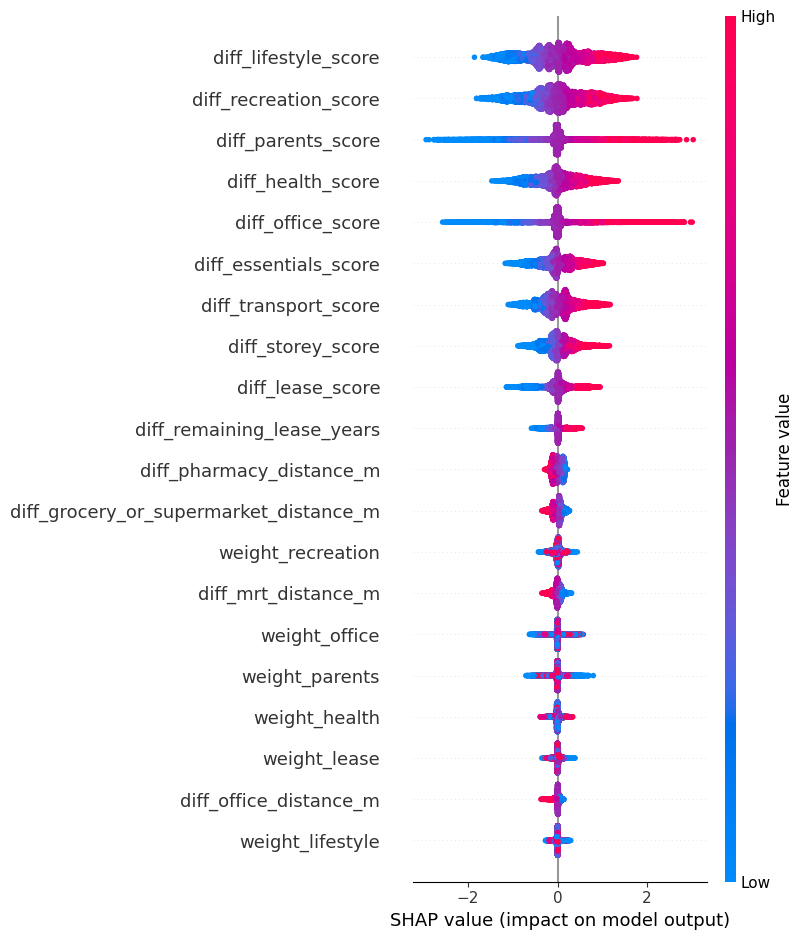

In [4]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, show=True)

### Bar Plot — Mean Absolute SHAP Values

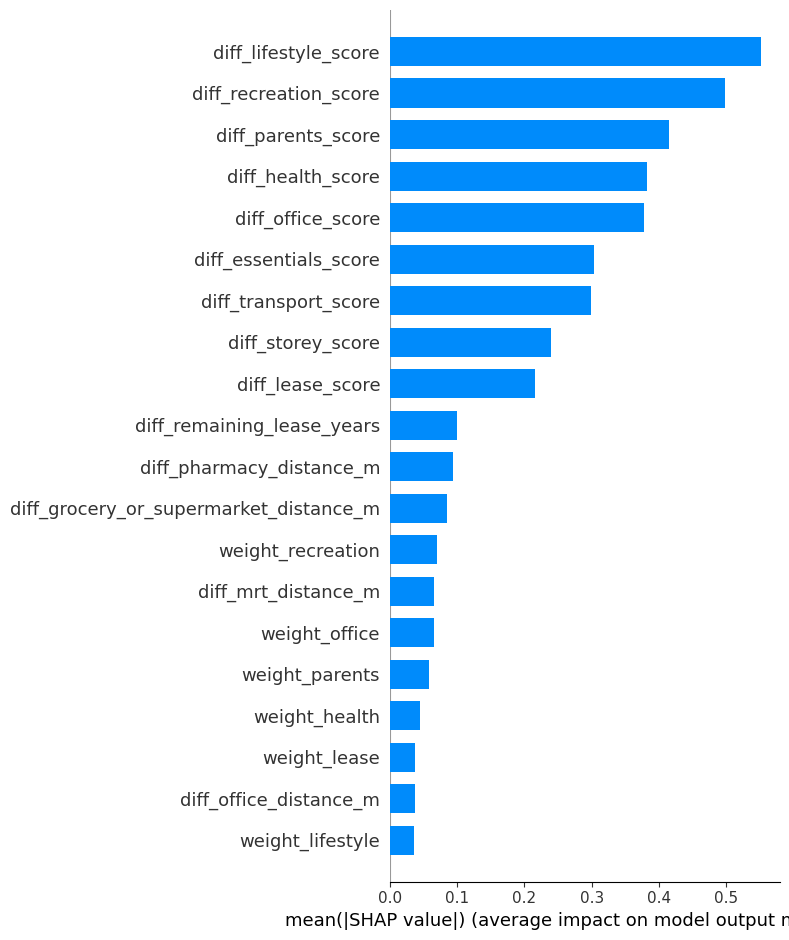

In [5]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, plot_type="bar", show=True)

### Dependence Plot — Weight × Score Interactions

Since the generative model is `sum(weight_i × score_i)`, we expect SHAP to show that  
`diff_transport_score` matters more when `weight_transport` is high.

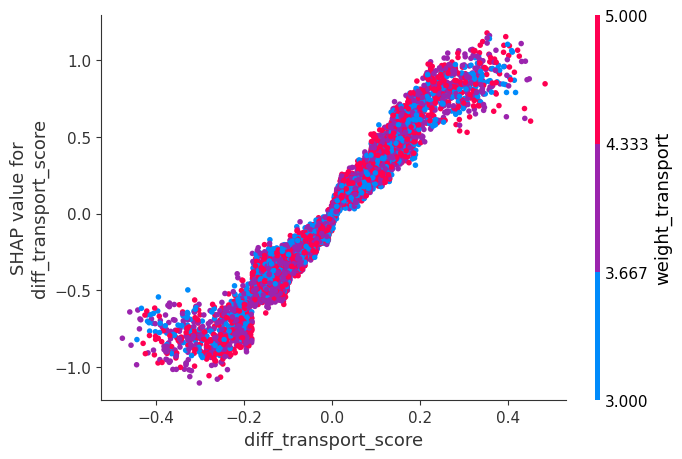

In [6]:
# Transport score dependence, colored by transport weight
shap.dependence_plot("diff_transport_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_transport",
                     show=True)

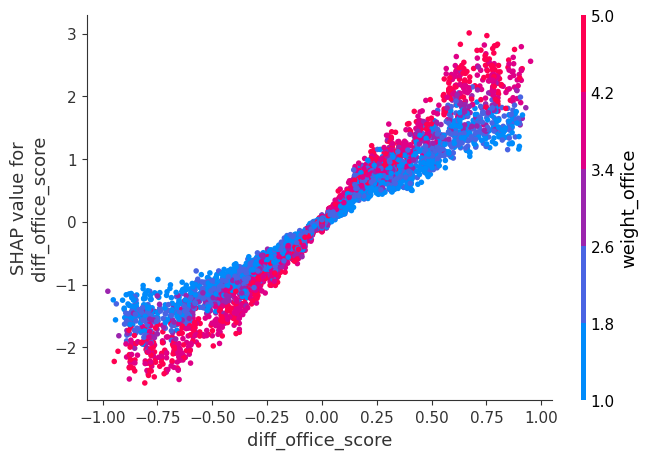

In [7]:
# Office score dependence, colored by office weight
shap.dependence_plot("diff_office_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_office",
                     show=True)

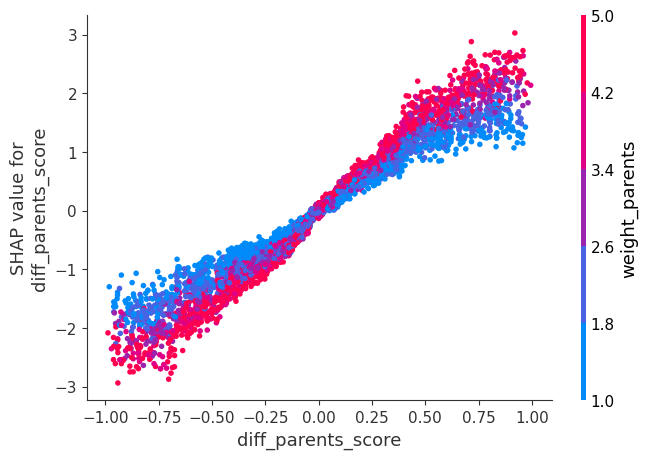

In [8]:
# Parents score dependence, colored by parents weight
shap.dependence_plot("diff_parents_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_parents",
                     show=True)

---
## 2. MLP (RankNet) — SHAP KernelExplainer

KernelExplainer is model-agnostic but slower, so we subsample the background dataset.

In [12]:
# Subsample background data for KernelExplainer (100 samples for speed)
np.random.seed(42)
bg_idx = np.random.choice(len(X_val_scaled), size=300, replace=False)
background = X_val_scaled[bg_idx]

# Subsample explanation set (200 samples)
explain_idx = np.random.choice(len(X_val_scaled), size=600, replace=False)
X_explain = X_val_scaled[explain_idx]

explainer_mlp = shap.KernelExplainer(mlp_best.predict_proba, background)
shap_values_mlp = explainer_mlp.shap_values(X_explain)

# SHAP v0.51+ returns (n_samples, n_features, n_classes) instead of a list
if isinstance(shap_values_mlp, list):
    shap_values_mlp_1 = shap_values_mlp[1]
else:
    shap_values_mlp_1 = shap_values_mlp[:, :, 1]
print(f"MLP SHAP values shape: {shap_values_mlp_1.shape}")

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 600/600 [01:42<00:00,  5.83it/s]

MLP SHAP values shape: (600, 36)


### Summary Plot — MLP (RankNet)

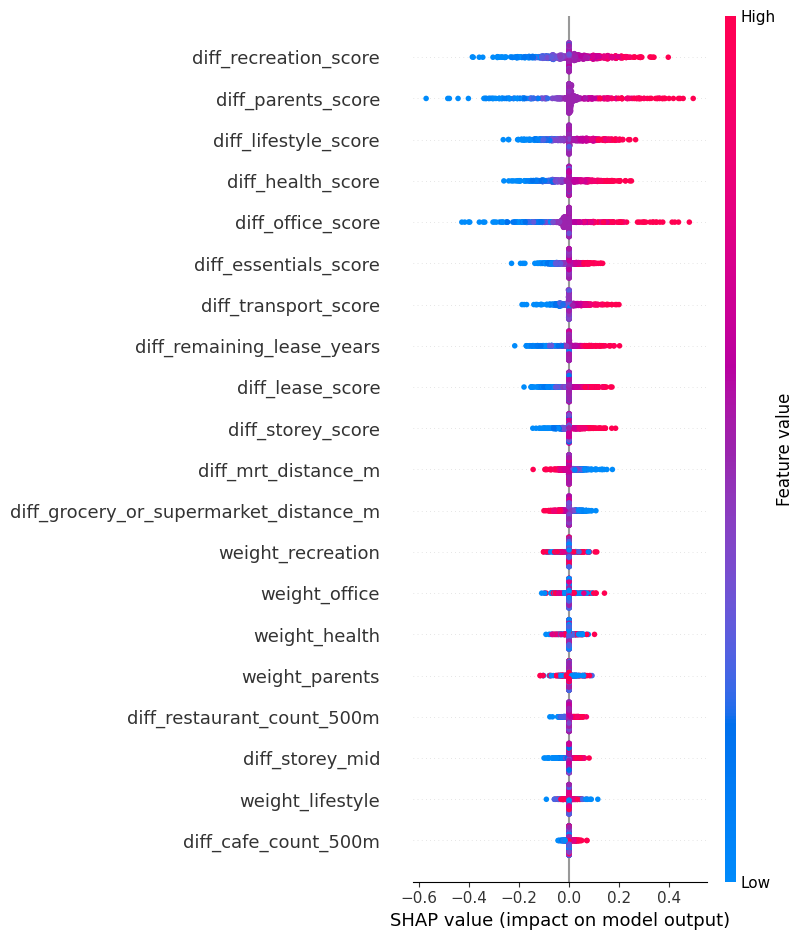

In [13]:
shap.summary_plot(shap_values_mlp_1, X_explain, feature_names=feature_cols, show=True)

---
## 3. Comparison: HistGBM vs MLP Feature Importance

Do both models agree on which features matter most?

In [14]:
# Mean absolute SHAP values per feature
hgb_importance = np.abs(shap_values_hgb).mean(axis=0)
mlp_importance = np.abs(shap_values_mlp_1).mean(axis=0)

comparison_df = pd.DataFrame({
    "feature": feature_cols,
    "HistGBM |SHAP|": hgb_importance,
    "MLP |SHAP|": mlp_importance,
})

# Rank features by importance for each model
comparison_df["HistGBM Rank"] = comparison_df["HistGBM |SHAP|"].rank(ascending=False).astype(int)
comparison_df["MLP Rank"] = comparison_df["MLP |SHAP|"].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values("HistGBM |SHAP|", ascending=False)

print("Feature Importance Comparison (Top 15)")
print("=" * 70)
comparison_df.head(15)

Feature Importance Comparison (Top 15)


,feature,HistGBM |SHAP|,MLP |SHAP|,HistGBM Rank,MLP Rank
11,diff_lifestyle_score,0.552177,0.066731,1,3
12,diff_recreation_score,0.498657,0.087776,2,1
17,diff_parents_score,0.415391,0.070237,3,2
13,diff_health_score,0.381522,0.056801,4,4
16,diff_office_score,0.378162,0.055834,5,5
10,diff_essentials_score,0.303533,0.032768,6,6
9,diff_transport_score,0.298873,0.032648,7,7
14,diff_storey_score,0.238962,0.024153,8,10
15,diff_lease_score,0.216124,0.024378,9,9
32,diff_remaining_lease_years,0.100393,0.028374,10,8


## 4. Explaining features of recommendation for MLP model

In [19]:
WEIGHT_LABELS = {
    "weight_transport":  "Transport (MRT/bus)",
    "weight_essentials": "Supermarket proximity",
    "weight_lifestyle":  "Cafes, restaurants & malls",
    "weight_recreation": "Parks & gyms",
    "weight_health":     "Clinics & pharmacies",
    "weight_storey":     "Floor level",
    "weight_lease":      "Remaining lease",
    "weight_office":     "Distance to workplace",
    "weight_parents":    "Distance to parents",
}

FEATURE_LABELS = {
    "diff_transport_score":               "Transport (MRT/bus)",
    "diff_essentials_score":              "Supermarket proximity",
    "diff_lifestyle_score":               "Cafes, restaurants & malls",
    "diff_recreation_score":              "Parks & gyms",
    "diff_health_score":                  "Clinics & pharmacies",
    "diff_storey_score":                  "Floor level",
    "diff_lease_score":                   "Remaining lease",
    "diff_office_score":                  "Distance to workplace",
    "diff_parents_score":                 "Distance to parents",
    "diff_mrt_distance_m":                "MRT distance (raw)",
    "diff_remaining_lease_years":         "Lease years (raw)",
    "diff_floor_area_sqm":                "Floor area (raw)",
}

def explain_flat_from_pairwise(mlp_best, scaler, df_pairwise,
                                feature_cols, weight_cols, uid, target_rank=1):
    user_pairs = df_pairwise[df_pairwise["user_id"] == uid].copy()

    # Print user preference profile
    user_weights = user_pairs[weight_cols].iloc[0]
    print(f"User {uid} — Preference Profile:")
    print("-" * 40)
    for col, val in user_weights.items():
        label = WEIGHT_LABELS.get(col, col)
        bar = "█" * int(val) + "░" * (5 - int(val))
        print(f"  {label:<30} {bar}  ({int(val)}/5)")
    print()

    # Aggregate win probability per flat_id_a
    input_scaled = scaler.transform(user_pairs[feature_cols].values)
    user_pairs["win_prob"] = mlp_best.predict_proba(input_scaled)[:, 1]

    flat_scores = user_pairs.groupby("flat_id_a")["win_prob"].mean().sort_values(ascending=False)
    target_flat = flat_scores.index[target_rank - 1]

    # Get all pairs where target flat is flat_a
    flat_pairs = user_pairs[user_pairs["flat_id_a"] == target_flat]
    flat_input_scaled = scaler.transform(flat_pairs[feature_cols].values)

    # KernelExplainer SHAP
    bg_idx = np.random.choice(len(input_scaled), size=min(50, len(input_scaled)), replace=False)
    background = input_scaled[bg_idx]

    explainer = shap.KernelExplainer(mlp_best.predict_proba, background)
    shap_vals = explainer.shap_values(flat_input_scaled, nsamples=200)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals[:, :, 1]
    mean_sv = sv.mean(axis=0)

    print(f"Rank #{target_rank} Recommendation: {target_flat}")
    print(f"Avg win probability: {flat_scores.iloc[target_rank - 1]:.2f}")
    print()

    # Waterfall plot
    shap_explanation = shap.Explanation(
        values=mean_sv,
        base_values=explainer.expected_value[1],
        data=flat_pairs[feature_cols].mean().values,
        feature_names=[FEATURE_LABELS.get(f, f) for f in feature_cols]
    )
    shap.waterfall_plot(shap_explanation, max_display=10)

    return shap_explanation

User U5 — Preference Profile:
----------------------------------------
  Transport (MRT/bus)            ███░░  (3/5)
  Supermarket proximity          ███░░  (3/5)
  Cafes, restaurants & malls     ██░░░  (2/5)
  Parks & gyms                   ████░  (4/5)
  Clinics & pharmacies           ██░░░  (2/5)
  Floor level                    ██░░░  (2/5)
  Remaining lease                ███░░  (3/5)
  Distance to workplace          █████  (5/5)
  Distance to parents            ██░░░  (2/5)



100%|██████████| 1/1 [00:00<00:00, 59.16it/s]

Rank #1 Recommendation: 1_TG PAGAR PLAZA_3 ROOM_
Avg win probability: 1.00



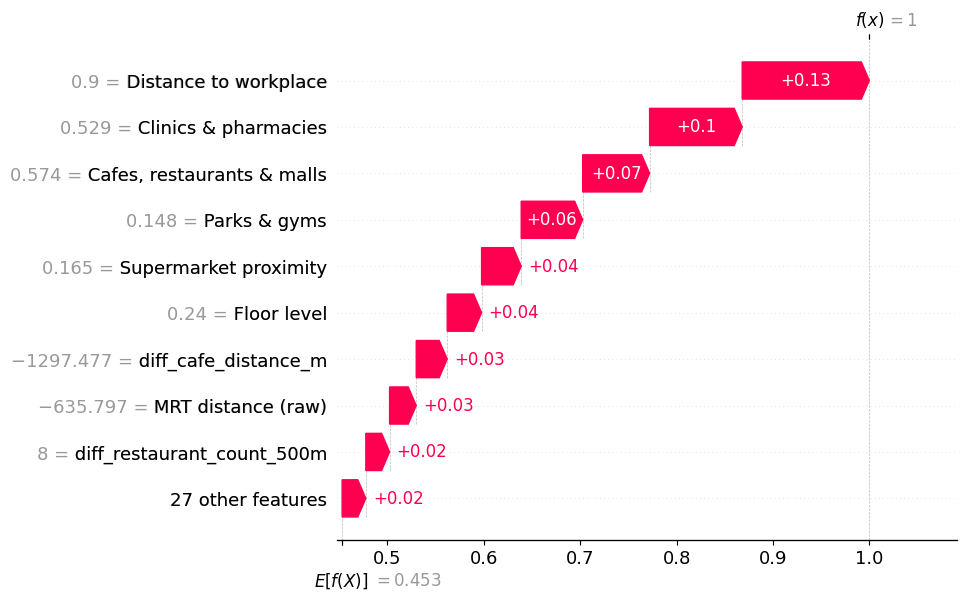

User U5 — Preference Profile:
----------------------------------------
  Transport (MRT/bus)            ███░░  (3/5)
  Supermarket proximity          ███░░  (3/5)
  Cafes, restaurants & malls     ██░░░  (2/5)
  Parks & gyms                   ████░  (4/5)
  Clinics & pharmacies           ██░░░  (2/5)
  Floor level                    ██░░░  (2/5)
  Remaining lease                ███░░  (3/5)
  Distance to workplace          █████  (5/5)
  Distance to parents            ██░░░  (2/5)



100%|██████████| 1/1 [00:00<00:00, 63.56it/s]


Rank #2 Recommendation: 205_TOA PAYOH NTH_3 ROOM_
Avg win probability: 1.00



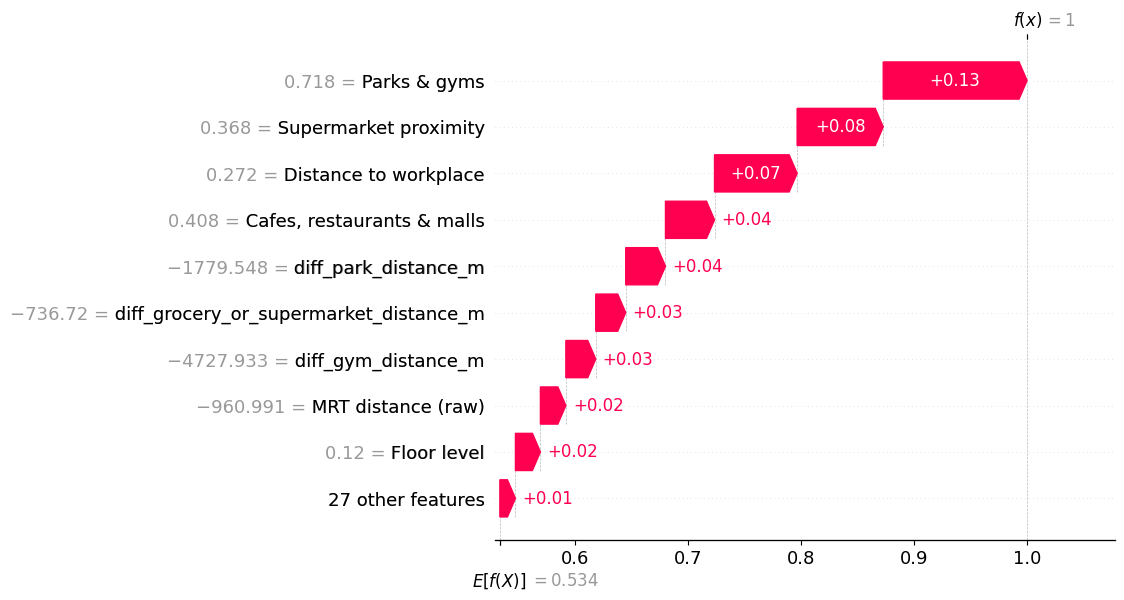

User U5 — Preference Profile:
----------------------------------------
  Transport (MRT/bus)            ███░░  (3/5)
  Supermarket proximity          ███░░  (3/5)
  Cafes, restaurants & malls     ██░░░  (2/5)
  Parks & gyms                   ████░  (4/5)
  Clinics & pharmacies           ██░░░  (2/5)
  Floor level                    ██░░░  (2/5)
  Remaining lease                ███░░  (3/5)
  Distance to workplace          █████  (5/5)
  Distance to parents            ██░░░  (2/5)



100%|██████████| 1/1 [00:00<00:00, 63.63it/s]

Rank #3 Recommendation: 73_LOR 4 TOA PAYOH_3 ROOM_
Avg win probability: 1.00



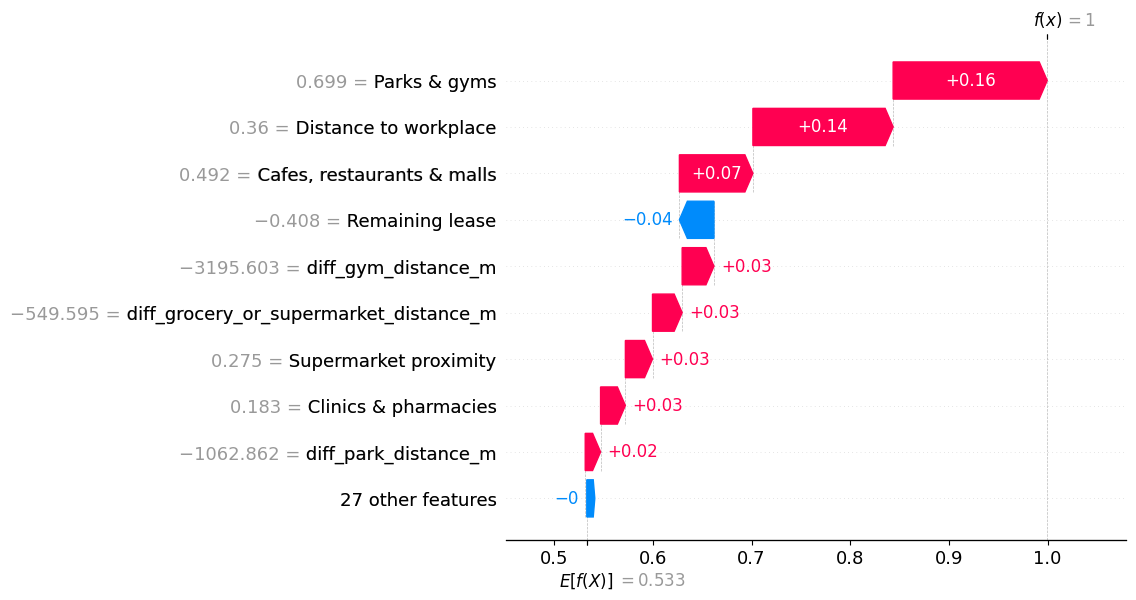

.values =
array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.02750409,  0.07453292,  0.15621848,  0.02514286,  0.        ,
       -0.03504623,  0.14217067,  0.        ,  0.        ,  0.        ,
        0.        ,  0.03006614,  0.        ,  0.        , -0.0016055 ,
        0.        ,  0.        ,  0.01556134,  0.03223971,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

.base_values =
np.float64(0.5329144930407618)

.data =
array([ 3.00000000e+00,  3.00000000e+00,  2.00000000e+00,  4.00000000e+00,
        2.00000000e+00,  2.00000000e+00,  3.00000000e+00,  5.00000000e+00,
        2.00000000e+00,  1.72639613e-04,  2.74797552e-01,  4.92125494e-01,
        6.99011682e-01,  1.83232270e-01,  1.20000000e-01, -4.08249158e-01,
        3.60397108e-01,  0.00000000e+00,  5.94276588e+01, -1.00197029e+02,
        1.00000000e+01, -5.4959510

In [29]:
# Usage
explain_flat_from_pairwise(mlp_best, scaler, df,
                            feature_cols, weight_cols, "U5", 1)
explain_flat_from_pairwise(mlp_best, scaler, df,
                            feature_cols, weight_cols, "U5", 2)
explain_flat_from_pairwise(mlp_best, scaler, df,
                            feature_cols, weight_cols, "U5", 3)